In [144]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [145]:
def percento(vals, percento):
    f1, f2 = vals
    delta = abs(f1 - f2)
    incremento = delta * percento / 100
    return [f1 - incremento, f2 + incremento]

In [146]:
def chi_quadro(xdata,ydata,par,modello):
    somma = 0.
    vx, vsx = xdata
    vy, vsy = ydata
    for i,(x,y) in enumerate(zip(vx,vy)):
        y_star = modello(par,x)
        chi = ((y-y_star)/vsy[i])**2
        somma += chi
    return somma

Importazione

In [147]:
anal,xdata,ydata = gf.importa_pickle("analisi.pkl")

def modello(par, x):
    a,b,d = par
    return a/b * np.exp(- ( x ) / d ) * ( 1/d * np.sin(b * ( x ) ) + b * np.cos(b * ( x ) ) )

Creazione array per v, omega e tau

In [148]:
[[v0, s_v], [omega0, s_omega], [tau0, s_tau]] = anal
risoluzione = 30
v = np.linspace(v0 - s_v, v0 + s_v, risoluzione)
omega = np.linspace(omega0 - s_omega, omega0 + s_omega, risoluzione)
tau = np.linspace(tau0 - s_tau, tau0 + s_tau, risoluzione)

### 1. Omega e Tau

In [149]:
O, T = np.meshgrid(omega, tau)
chi_quadri = np.zeros_like(O)

for i in range(O.shape[0]):
    for j in range(O.shape[1]):
        parametri = [anal[0][0], O[i, j], T[i, j]]
        chi_quadri[i, j] = chi_quadro(xdata, ydata, parametri, modello)

In [150]:
zoom = 50

x = [omega0 - s_omega, omega0 + s_omega]
y = [tau0 - s_tau, tau0 + s_tau]
z = [chi_quadri.min(), chi_quadri.max()]
xlim = percento(x, zoom)
ylim = percento(y, zoom)
zlim = percento(z, zoom)

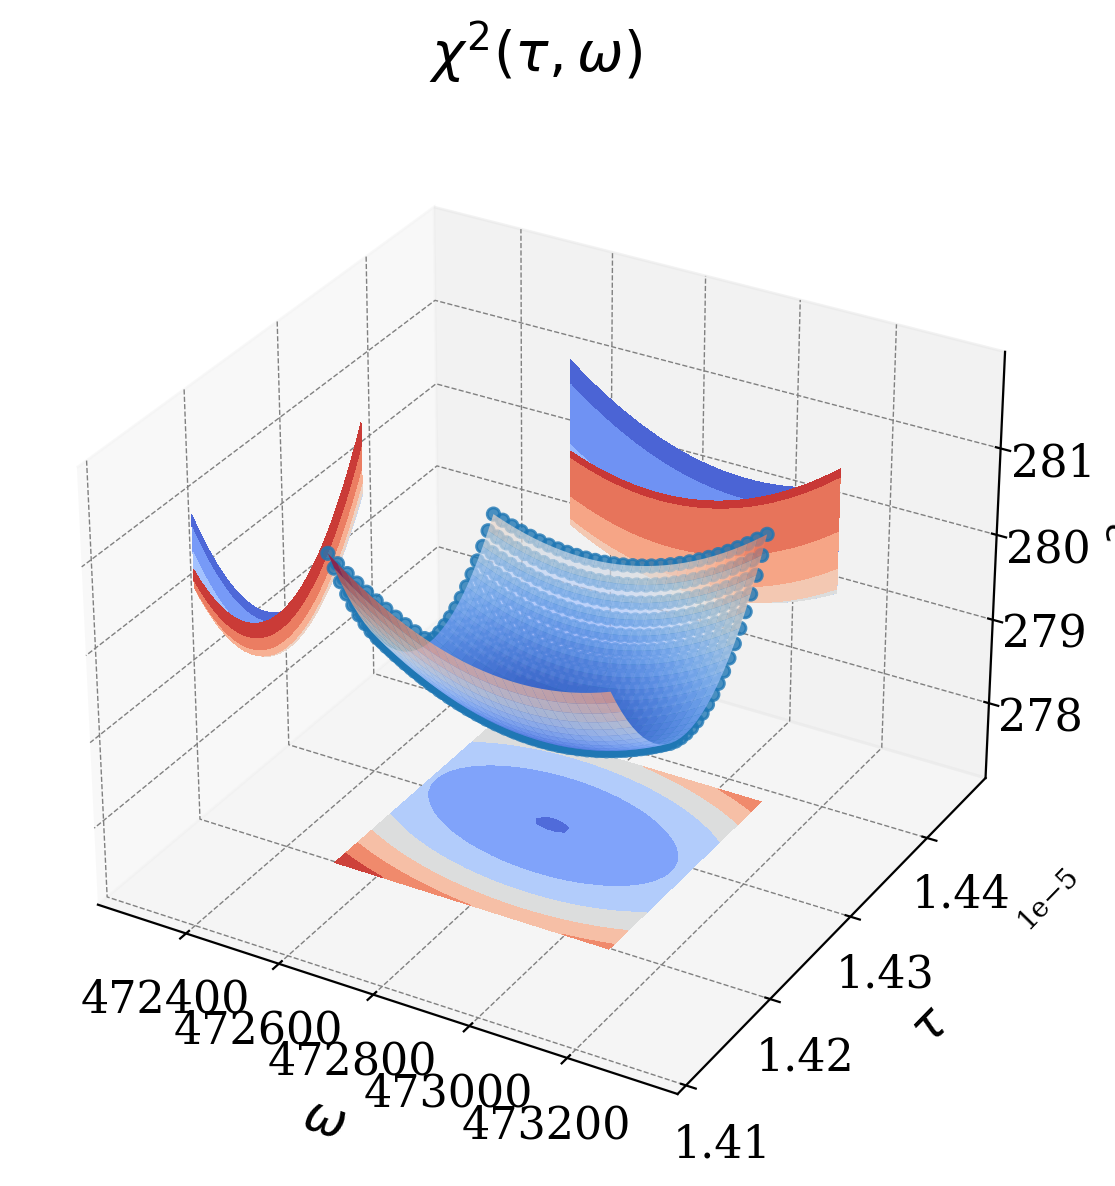

In [151]:
fig = plt.figure()

ax1 = fig.add_subplot(1,1,1, projection='3d')
gf.parametri_grafico(ax1,r"$\chi^2 ( \tau,\omega )$",xlabel=r"$\omega$",ylabel=r"$\tau$",zlabel=r"$\chi^2$",tridimensionale=True)
ax1.scatter(O, T, chi_quadri, **gf.scatter_params)
ax1.plot_surface(O, T, chi_quadri, cmap='coolwarm', alpha=0.7)
ax1.contourf(O, T, chi_quadri, zdir='x', offset=xlim[0], cmap='coolwarm')
ax1.contourf(O, T, chi_quadri, zdir='y', offset=ylim[1], cmap='coolwarm')
ax1.contourf(O, T, chi_quadri, zdir='z', offset=zlim[0], cmap='coolwarm')
ax1.set(xlim=xlim, ylim=ylim, zlim=zlim)

gf.salva_grafico(fig,"Chi/omega_tau_3d.pdf")

In [152]:
"""
fig = plt.figure()

ax1 = fig.add_subplot(2,2,2)
gf.parametri_grafico(ax1,r"$\chi^2 ( \tau,\omega )$",xlabel=r"$\omega$",ylabel=r"$\tau$")
colore = ax1.pcolormesh(O, T, chi_quadri, shading='auto', cmap='viridis')
fig.colorbar(colore, ax=ax1, label=r"$\chi^2$")

ax2 = fig.add_subplot(2,2,1)
gf.parametri_grafico(ax2,r"$\chi^2 ( \tau )$",xlabel=r"$\tau$",ylabel=r"$\chi^2$")
ax2.scatter(T, chi_quadri, **gf.scatter_params)

ax3 = fig.add_subplot(2,2,4)
gf.parametri_grafico(ax3,r"$\chi^2 ( \omega )$",xlabel=r"$\omega$",ylabel=r"$\chi^2$")
ax3.scatter(O, chi_quadri, **gf.scatter_params)

gf.salva_grafico(fig,"Chi/omega_tau_2d.pdf")
"""

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_40792/1759256506.py:1: SyntaxWarning: invalid escape sequence '\c'
  """


'\nfig = plt.figure()\n\nax1 = fig.add_subplot(2,2,2)\ngf.parametri_grafico(ax1,r"$\\chi^2 ( \tau,\\omega )$",xlabel=r"$\\omega$",ylabel=r"$\tau$")\ncolore = ax1.pcolormesh(O, T, chi_quadri, shading=\'auto\', cmap=\'viridis\')\nfig.colorbar(colore, ax=ax1, label=r"$\\chi^2$")\n\nax2 = fig.add_subplot(2,2,1)\ngf.parametri_grafico(ax2,r"$\\chi^2 ( \tau )$",xlabel=r"$\tau$",ylabel=r"$\\chi^2$")\nax2.scatter(T, chi_quadri, **gf.scatter_params)\n\nax3 = fig.add_subplot(2,2,4)\ngf.parametri_grafico(ax3,r"$\\chi^2 ( \\omega )$",xlabel=r"$\\omega$",ylabel=r"$\\chi^2$")\nax3.scatter(O, chi_quadri, **gf.scatter_params)\n\ngf.salva_grafico(fig,"Chi/omega_tau_2d.pdf")\n'

In [153]:
del x, y, z, xlim, ylim, zlim, O, T, chi_quadri

### 2. V e Tau

In [154]:
V, T = np.meshgrid(v, tau)
chi_quadri = np.zeros_like(V)

for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        parametri = [V[i, j], anal[1][0], T[i, j]]
        chi_quadri[i, j] = chi_quadro(xdata, ydata, parametri, modello)

In [155]:
zoom = 50

x = [v0 - s_v, v0 + s_v]
y = [tau0 - s_tau, tau0 + s_tau]
z = [chi_quadri.min(), chi_quadri.max()]
xlim = percento(x, zoom)
ylim = percento(y, zoom)
zlim = percento(z, zoom)

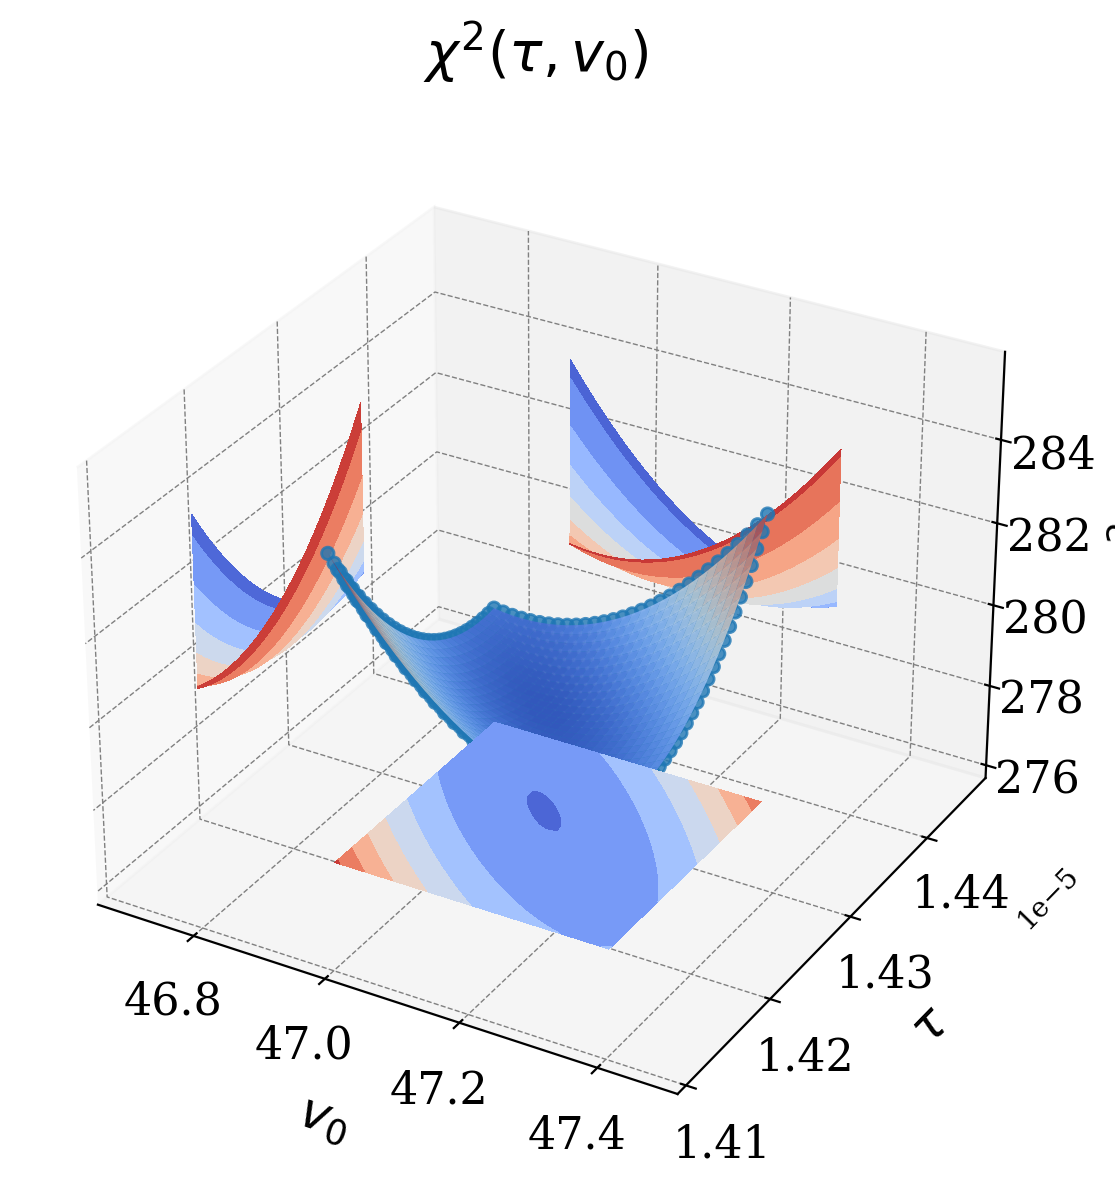

In [156]:
fig = plt.figure()

ax1 = fig.add_subplot(1,1,1, projection='3d')
gf.parametri_grafico(ax1,r"$\chi^2 ( \tau, v_0 )$",xlabel=r"$v_0$",ylabel=r"$\tau$",zlabel=r"$\chi^2$",tridimensionale=True)
ax1.scatter(V, T, chi_quadri, **gf.scatter_params)
ax1.plot_surface(V, T, chi_quadri, cmap='coolwarm', alpha=0.7)
ax1.contourf(V, T, chi_quadri, zdir='x', offset=xlim[0], cmap='coolwarm')
ax1.contourf(V, T, chi_quadri, zdir='y', offset=ylim[1], cmap='coolwarm')
ax1.contourf(V, T, chi_quadri, zdir='z', offset=zlim[0], cmap='coolwarm')
ax1.set(xlim=xlim, ylim=ylim, zlim=zlim)

gf.salva_grafico(fig,"Chi/v_tau_3d.pdf")

In [157]:
"""
fig, ax = plt.subplots()
gf.parametri_grafico(ax,r"$\chi^2 ( \tau, v_0 )$",xlabel=r"$v_0$",ylabel=r"$\tau$")

colore = ax.pcolormesh(V, T, chi_quadri, shading='auto', cmap='viridis')

fig.colorbar(colore, ax=ax, label=r"$\chi^2$")

gf.salva_grafico(fig,"Chi/v_tau_2d.pdf")
"""

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_40792/2278907907.py:1: SyntaxWarning: invalid escape sequence '\c'
  """


'\nfig, ax = plt.subplots()\ngf.parametri_grafico(ax,r"$\\chi^2 ( \tau, v_0 )$",xlabel=r"$v_0$",ylabel=r"$\tau$")\n\ncolore = ax.pcolormesh(V, T, chi_quadri, shading=\'auto\', cmap=\'viridis\')\n\nfig.colorbar(colore, ax=ax, label=r"$\\chi^2$")\n\ngf.salva_grafico(fig,"Chi/v_tau_2d.pdf")\n'

In [158]:
del xlim,ylim,zlim, V, T, chi_quadri